## Correlation Heatmap

A correlation matrix contains the pairwise linear correlations between numerical variables. A heatmap provides a visual representation of this matrix using colors, making it easier to identify positive, negative, and weak relationships.

The correlation coefficient ranges from -1 to +1:

- Values close to +1 indicate a strong positive linear relationship.
- Values close to -1 indicate a strong negative linear relationship.
- Values close to 0 indicate a weak or negligible linear relationship.

A heatmap is particularly useful when a dataset contains multiple numerical variables because relationships can be identified quickly through visual patterns.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("D:/02_Courses_Learning/Data Science/Data-Science-Journey/Projects/Students_performance_analysis/Data/student_performance.csv")

### Creating the Correlation Matrix

Before creating the heatmap, we calculate the correlation matrix for the numerical variables in the dataset.

In [2]:
correlation_matrix = df[
    ["study_hours", "attendance", "previous_marks", "final_marks"]
].corr()

correlation_matrix

,study_hours,attendance,previous_marks,final_marks
study_hours,1.000000,0.198402,-0.111173,0.479582
attendance,0.198402,1.000000,0.095716,0.387515
previous_marks,-0.111173,0.095716,1.000000,0.462367
final_marks,0.479582,0.387515,0.462367,1.000000


### Visualizing the Correlation Matrix

The correlation matrix can be visualized using a Seaborn heatmap. This makes it easier to compare the strength and direction of relationships between variables.

In [3]:
import seaborn as sns

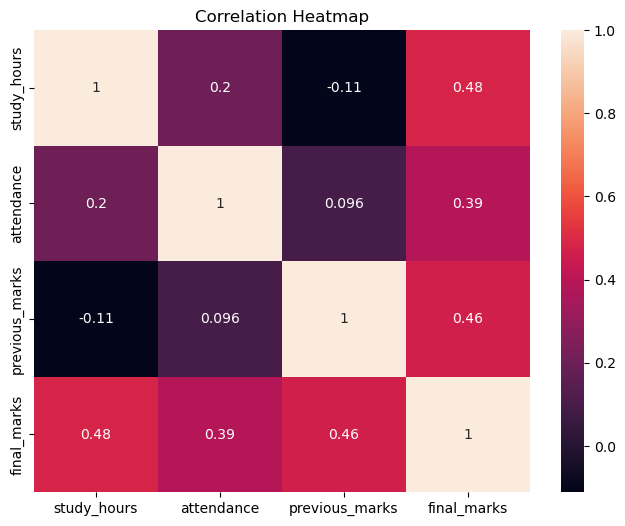

In [6]:
plt.figure(figsize=(8, 6))

sns.heatmap(correlation_matrix, annot=True)

plt.title("Correlation Heatmap")

plt.show()

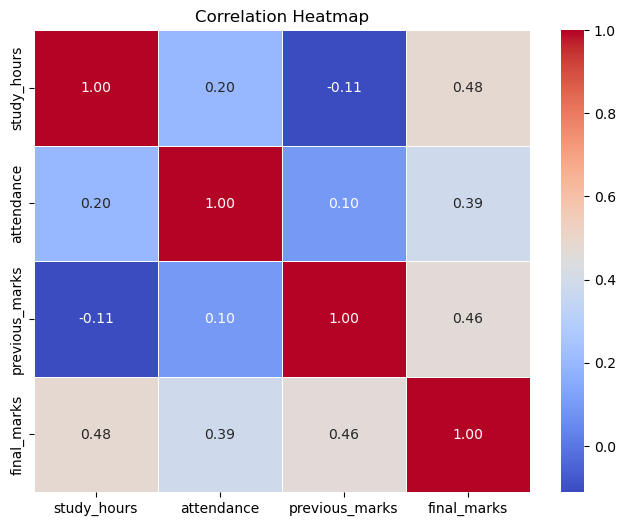

In [7]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

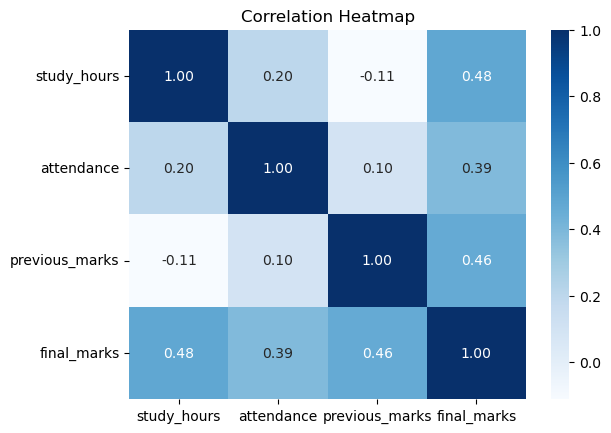

In [8]:
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Correlation Heatmap")
plt.show()

### Interpretation

The heatmap shows the pairwise correlations between the numerical variables.

The main observations are:

- Study hours and final marks show a moderate positive correlation (r ≈ 0.48).
- Previous marks and final marks show a moderate positive correlation (r ≈ 0.46).
- Attendance and final marks show a weaker positive correlation (r ≈ 0.39).
- Study hours and previous marks show a very weak negative correlation (r ≈ -0.11).

Among the variables analyzed, study hours has the highest positive correlation with final marks.

However, correlation represents association and does not imply causation. These findings are specific to the available dataset.

In [12]:
correlation_matrix["final_marks"].drop("final_marks").idxmax()

'study_hours'

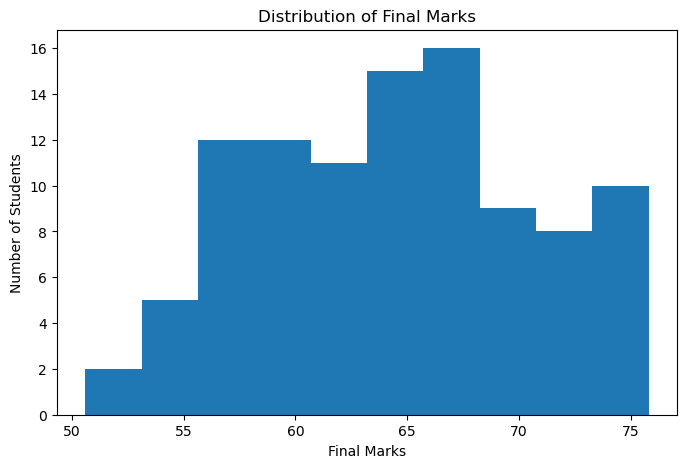

In [14]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["final_marks"],
    bins=10
)

plt.xlabel("Final Marks")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Marks")

plt.show()

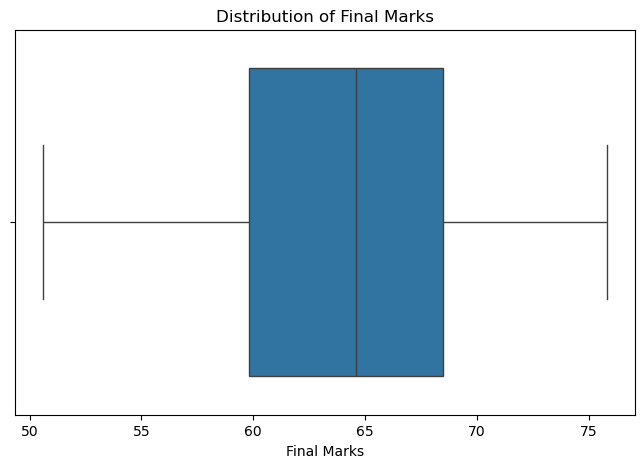

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["final_marks"])

plt.xlabel("Final Marks")
plt.title("Distribution of Final Marks")

plt.show()

In [16]:
Q1 = df["final_marks"].quantile(0.25)
Q3 = df["final_marks"].quantile(0.75)

Q1, Q3

(np.float64(59.8), np.float64(68.5))

In [17]:
IQR = Q3 - Q1

IQR

np.float64(8.700000000000003)

In [18]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound

(np.float64(46.74999999999999), np.float64(81.55000000000001))

In [19]:
outliers = df[
    (df["final_marks"] < lower_bound) |
    (df["final_marks"] > upper_bound)
]

outliers

,student_id,gender,study_hours,attendance,previous_marks,final_marks


## Outlier Detection Using IQR

A box plot can help identify potential outliers visually. To verify the presence of outliers programmatically, the Interquartile Range (IQR) method is used.

The IQR is calculated as:

IQR = Q3 - Q1

Potential outlier boundaries are calculated using:

Lower Bound = Q1 - 1.5 × IQR
Upper Bound = Q3 + 1.5 × IQR

For the final marks variable:

- Q1 = 59.8
- Q3 = 68.5
- IQR = 8.7
- Lower Bound = 46.75
- Upper Bound = 81.55

No observations were found outside these boundaries. Therefore, the dataset contains no potential outliers in final marks according to the IQR method.

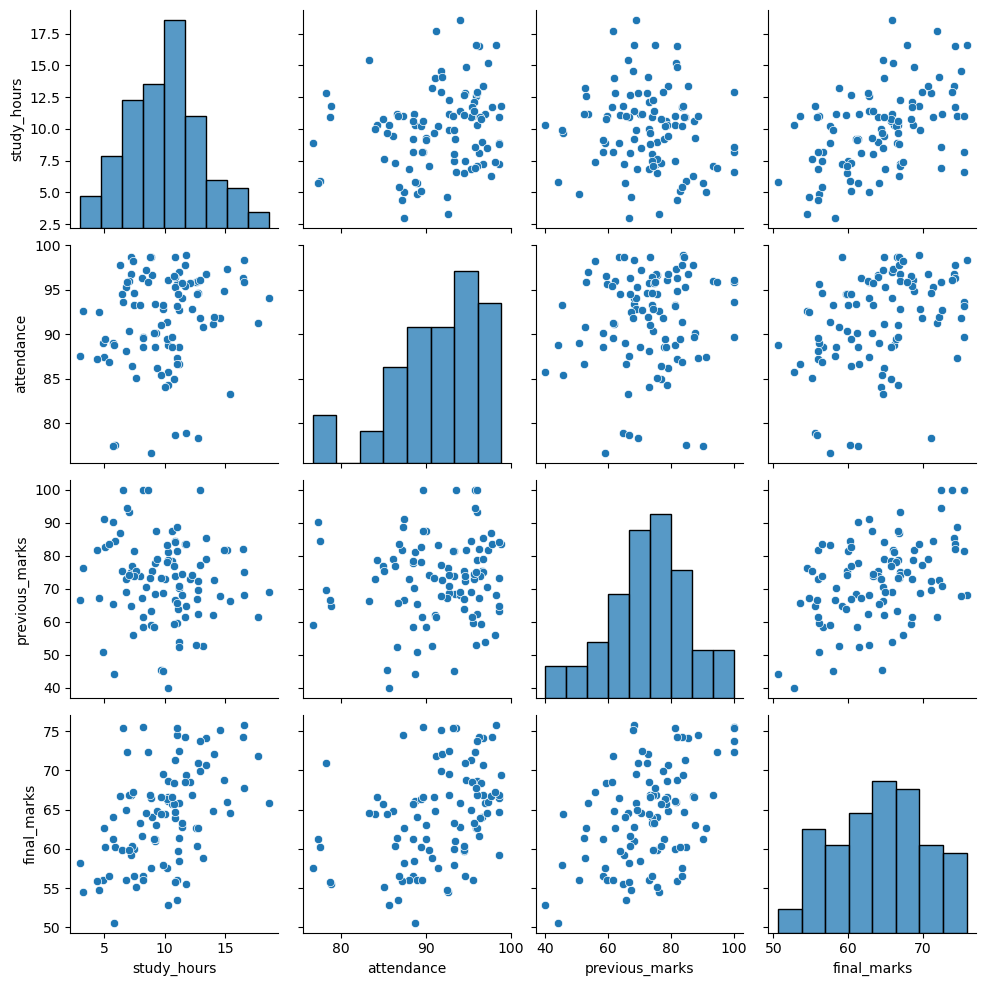

In [21]:
numerical_df = df[
    ["study_hours", "attendance", "previous_marks", "final_marks"]
]
sns.pairplot(numerical_df)

plt.show()